In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

In [19]:
import langchain
langchain.__version__

'1.4.3'

# Agents

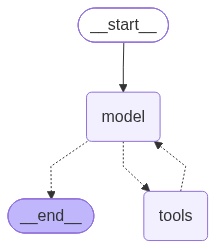

In [5]:
from langchain.agents import create_agent

def get_weather(city:str)-> str:
    """Get the weather for a given city."""
    return f"The weather in {city} is sunny."

agent = create_agent(
    model = "google_genai:gemini-3.8-flash",
    tools = [get_weather],
    system_prompt = "You are a helpful assistant."
)
agent


In [8]:
# run the agent
response = agent.invoke({"messages": [{"role": "user", "content": "What is the weather in New York?"}]})

In [10]:
response

{'messages': [HumanMessage(content='What is the weather in New York?', additional_kwargs={}, response_metadata={}, id='69eb8c61-c24c-44d0-b5aa-fedcfdd01f3b'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "New York"}'}, '__gemini_function_call_thought_signatures__': {'call_510861': 'EoUCCoICAWkUfROCWPbR6ptW/DNfUTkKIuNV3tZA2ZGAs4wCpqqmDabL4k3NcyD+j1w2yPaW4aoW99e9M7Tr5Yt4al+mGOTLRuJMjbmEnWsD75F1kXe0GpP4g1YWx+RRK4z43s9NMI3fsxHkgEcLEnLWacb/sL6rCBo2Dh4GGdJIdoQ7FRxnCiad18BR7hV2aojPxFINaIyWTANHX4eHTMfOXqQe0JxqYhn7l0+VaSr4Fdblyb9BYEo6Vghxp5Y2bgMv7E6WMSEAztSo35KZaBpownJcggku3Qn1HyzjPclvPkKFc2NSQYXIaaEPngsOe1leiY1sW/K8q6D8vg2odFOEwqGcAwIp'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.8-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a121aa-6f0b-7a71-8507-f96e1aa460b3-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'call_510861', 'type': 'tool_call'}], 

In [9]:
response["messages"][-1].content

[{'type': 'text',
  'text': 'The weather in New York is currently sunny.',
  'extras': {'signature': 'EtUBCtIBAWkUfRNfcCSuo7ftUNkfcS/R/JDjReVPFbdbfdLtqWVGt/bIdPqMzhvhmJGpDFRiiuDItxI4rlXzD5hDq9U3P1ZSS+DrZCzHws8wW/DM4hfEgNEpNKUFEGIBJ/7T1PP76RbPohren8BwcdLq5tWURji0Qt6nOTJk4aYxGDAoYqt9IEcOP3M++RkZ9pljj5ZqdWxuB1OrCYiw4UKMUTtz7tIw08DocSJv+kTbgLqkjmTOglLuYpdTZmuYMg6qL6HVS4+Cxl2j8atxaJWLV1hXFrWI'}}]

In [17]:
agent.invoke({"messages":"What is the weather in New York?"})

{'messages': [HumanMessage(content='What is the weather in New York?', additional_kwargs={}, response_metadata={}, id='483cba66-f020-471c-aa41-b87ad06ae2c3'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "New York"}'}, '__gemini_function_call_thought_signatures__': {'call_2156902': 'EoECCv4BAWkUfRORmmRwn9zdynNP7avzTNBkyJT4UiKlXgMSG8JrjGZSRohG7fR1/T61HqXiOb8d2WJPe6D3cuGqM28pMFZ9+zffMcMQOYjX/hz4CLcix48IcDwdGv4WzaA5keabhVmri/vbNbTWhz2JKhbS8+6SERMm7DXNIM75btE6L60zNjVJoXF1zi2ILAGkaMlomM4t2yszf+WOFyrJxQML8cleIb7qazTPgOqZo59IS7yKkj6+FyLzv+mcjggLi8H5qVP5Gi627JmxySjnHQMjbxT/yXLD4IhnD57FHbRbOMpxOIY+jMEQgSKzKmRJGdwiQrG7yPWvhuBhBBXqx58='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.8-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a121b6-06bd-77a2-8e72-6eb3a14651c5-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'call_2156902', 'type': 'tool_call'}], in